# EMERGING TECHNOLOGIES ASSIGNMENT 2026

Dan Steve Mukulupi

G00360836

In [31]:
# Imports

# Random selections.
import random 

# Numerical arrays.
import numpy as np

# Permutations and combinations
import itertools

# Dataframes.
import pandas as pd

# Plotting.
import matplotlib.pyplot as plt

## PROBLEM 1: GENERATING RANDOM BOOLEAN FUNCTIONS 

## 1.  Introduction

The goal of this problem is to construct a Python function that generates Boolean functions with four inputs. Each generated function must satisfy one of two strict conditions:

. It must be constant

. Or balanced

This constraint defines a structured subset of all possible Boolean functions.

## What is a Boolean Function ?

A Boolean Function is a function that takes boolean inputs (0 or 1) and produces a boolean output.

Boolean Type has only two possible values:

True or False


## Constant and Balanced Boolean Functions Types

1. Constant Boolean Functions: A Boolean function is constant if it produces the same output for all possible input combinations. 
There are two types of constant boolean functions: One that always outputs 0 and another that always outputs 1.

2. Balanced Boolean Functions: A Boolean function is balanced if it produces 0 and 1 outputs with equal probability. 
in other words, half of the possible  input combinations result in an output of 0, and the other half result in an output of 1

## What is Deutsh-Jozsa Algorithm?

The Deutsch-Jozsa algorithm is a quantum procedure that distinguishes between two specific classes of boolean functions: those that are constant and those that are balanced. 



 <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>f</mi>
  <mo>:</mo>
  <mrow>
    <msup>
      <mrow data-mjx-texclass="ORD">
        <mn>0</mn>
        <mo>,</mo>
        <mn>1</mn>
      </mrow>
      <mi>n</mi>
    </msup>
    <mo stretchy="false">&#x2192;</mo>
    <mrow data-mjx-texclass="ORD">
      <mn>0</mn>
      <mo>,</mo>
      <mn>1</mn>
    </mrow>
  </mrow>
</math>

=> Constant: f(x) = C for all x, where  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>c</mi>
  <mo>&#x2208;</mo>
  <mrow data-mjx-texclass="ORD">
    <mn>0</mn>
    <mo>,</mo>
    <mn>1</mn>
  </mrow>
</math>

=> Balanced: f(x) = 0 for exactly half of the inputs and f(x) = 1 for the other half.

## Superposition

## Comparison with Classical Algorithms

Classical algorithms for determining whether a Boolean function is constant or balanced require evaluating the function on multiple input combinations

In contrast, the Deutsch-Jozsa Algorithm evaluates the Boolean function on all possible input combinations simultaneously using quantum parallelism, requiring only a single evaluation.



## Solution

Total no of combinations = 2<sup>n</sup> 

Where, n = no. of variables

4 Boolean Inputs

2<sup>4</sup> = 16 possible inputs Combinations 

1. ### Constant Function

False = 0 input Combinations

True = 16 input combinations

or 

False = 16

True = 0

2. ### Balanced Function

True = 8 inputs

False = 8 inputs


In [28]:
# Create a random_constant_balanced function

def random_constant_balanced():
    """
    Create a random boolean function that takes four boolean arguments as inputs and each function is guaranteed to be either
    constant (always returns False or always returns True) or
    balanced (returns True for exactly half of the input combinations and False for the other half).
    """

    # Generate all possible combinations of four boolean inputs (16 combinations).
    all_input_combinations = list(itertools.product([False, True], repeat=4))

    # Randomly decide whether to create a constant or balanced function.
    ftype = random.choice(["constant", "balanced"])

    # Store output mapping for all input combinations.
    output_map = {}

    if ftype == "constant":
        output_value = random.choice([False, True])
        for input_combo in all_input_combinations:
            output_map[input_combo] = output_value
    else:
        # Pick half of the combinations to be True and the other half to be False.
        true_inputs = set(random.sample(all_input_combinations, len(all_input_combinations) // 2))

        for input_combo in all_input_combinations:
            output_map[input_combo] = input_combo in true_inputs

    # Function that uses the mapping
    def boolean_function(*args):
        return output_map[tuple(args)]

    return boolean_function


# Test the function
test_function = random_constant_balanced()

all_cases = list(itertools.product([False, True], repeat=4))
outputs = [test_function(*inputs) for inputs in all_cases]

# Calculate the number of True and False outputs
true_num = sum(outputs)
false_num = len(outputs) - true_num

# Print results
print("True outputs:", true_num)
print("False outputs:", false_num)

True outputs: 16
False outputs: 0


## Section 1: Generating All Input Combinations

### Context

A Boolean function with four inputs must define an outputs for every possible combination of those inputs. since each input can be either True or False, the total number of combinations is 2<sup>4</sup>  = 16. This section generates the full input space using itertools.product, which systematically constructs every possible tuple of four Boolean values. This forms the foundation for defining and evaluating any Boolean function in this problem

In [41]:
# Generate all possible combinations of four boolean inputs (16 combinations).
all_inputs = list(itertools.product([False, True], repeat=4))

# Print information about the input combinations
print("TOTAL NUMBER OF INPUT COMBINATIONS:", len(all_inputs))
print("\nFIRST 5 INPUT COMBINATIONS:\n")
for i in range(5):
    print(all_inputs[i])

TOTAL NUMBER OF INPUT COMBINATIONS: 16

FIRST 5 INPUT COMBINATIONS:

(False, False, False, False)
(False, False, False, True)
(False, False, True, False)
(False, False, True, True)
(False, True, False, False)


### Summary
This step  ensures that the complete input space is available for constructing both Constant and Balanced Boolean Functions

## Section 2: Understanding Constant Functions

### Context

### Always returns TRUE

A constant Boolean function is one that produces the same output for every possible input. It completely ignores its inputs and always returns either True or False. in this example, a simple constant function is defined that always returns True. The function is then evaluated across all 16 input combinations to confirm that its output never changes, demonstrating the defining property of constant functions. 

In [40]:
# Example of a constant function (always True) 
def constant_true(a, b, c, d):
    return True

# Generate outputs for the constant function
outputs = [constant_true(*inp) for inp in all_inputs]

# Calculate the number of True and False outputs
print("CONSTANT TRUE FUNCTION OUTPUTS:\n") 
print("TRUE COUNT:", sum(outputs))
print("FALSE COUNT:", len(outputs) - sum(outputs))

CONSTANT TRUE FUNCTION OUTPUTS:

TRUE COUNT: 16
FALSE COUNT: 0


### Context

### Always returns FALSE

A constant Boolean function is one that produces the same output for every possible input. It completely ignores its inputs and always returns either True or False. in this example, a simple constant function is defined that always returns False. The function is then evaluated across all 16 input combinations to confirm that its output never changes, demonstrating the defining property of constant functions. 

In [42]:
# Example of a constant function (always False)
def constant_false(a, b, c, d):
    return False

# Generate outputs for the constant function
outputs = [constant_false(*inp) for inp in all_inputs]

# Calculate the number of True and False outputs
print("\nCONSTANT FALSE FUNCTION OUTPUTS:\n")
print("TRUE COUNT:", sum(outputs))
print("FALSE COUNT:", len(outputs) - sum(outputs))


CONSTANT FALSE FUNCTION OUTPUTS:

TRUE COUNT: 0
FALSE COUNT: 16


### Summary
This step confirms that constant functions produce identical outputs regardless of input, satisfying one of the two valid function types required in this problem

## Section 3: Understanding Balanced Functions

### Context

A balanced Boolean function is defined as one that outputs True for exactly half of all possible inputs and False for the remaining half. for four inputs, this means exactly 8 out of 16 outputs must be True. This section demonstrates the concept by manually constructing a balanced output distribution and verifying that the counts are equal 

In [43]:
# Create a simple balanced function manually
# 8 True and 8 False outputs
balanced_outputs = [True]*8 + [False]*8  

print("BALANCE FUNCTION OUTPUTS:\n")
print("TRUE COUNT:", sum(balanced_outputs))
print("FALSE COUNT:", len(balanced_outputs) - sum(balanced_outputs))

BALANCE FUNCTION OUTPUTS:

TRUE COUNT: 8
FALSE COUNT: 8


### Summary
This shows the defining property of balanced functions: an exact 50/50 split between outputs

## Section 4: Random Selection of Function Type

### Explaination Context
To satisfy the requirements of generating a randomly chosen Boolean function, the program must randomly select between a constant function and a balanced function. this section demonstrates repeated random selection using random.choice, showing that both function types can be produced unpredictably. This randomness is essential to ensure that the generator does not always produce the same kind of function.  

In [46]:
# Randomly choosing function type
for _ in range(5): 
     ftype = random.choice(["CONSTANT", "BALANCED"])
     print("GENERATED FUNCTION TYPE:", ftype) 

GENERATED FUNCTION TYPE: CONSTANT
GENERATED FUNCTION TYPE: BALANCED
GENERATED FUNCTION TYPE: CONSTANT
GENERATED FUNCTION TYPE: BALANCED
GENERATED FUNCTION TYPE: CONSTANT


#### Summary
This confirms that function type selection is stochastic, ensuring variability in generated functions. 

## Section 5: Mapping Inputs to Outputs

### Explaination Context
A Boolean function can be represented using a lookup table, where each input combination is mapped directly to a corresponding output value. This structure ensures that every possible input has a defined result. In this example, a dictionary is used to store the mapping, demonstrating how inputs are systematically associated with outputs in a constant function.



In [47]:
# lookup table construction 
example_map = {} 

for inp in all_inputs:
    # simple constant mapping
    example_map[inp] = True 

# Print the mapping for the first 5 input combinations
    print("EXAMPLE MAPPING (FIRST 5 ENTRIES):\n")
    for i, (k, v) in enumerate(example_map.items()):
        if i == 5:
            break
        print(k, " -> ", v)

EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
(False, False, True, True)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
(False, False, True, True)  ->  True
(False, True, False, False)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
(False, False, True, True)  ->  True
(False, True, False, False)  ->  True
EXAMPLE MAPPING (FIRS

### Summary
This illustrates how Boolean functions are implemented internally as explit mappings from inputs to outputs

## Section 6: Full Truth Table Representation
### Explanation Context

A Boolean function is fully defined by its truth table, which lists every possible input combination alongside its corresponding output. This section generates a complete truth table for a randomly created function and displays it in a structured format. This makes it easy to visually inspect whether the function is constant or balanced by examining patterns in the output column.

In [ ]:
test_function = random_constant_balanced()

all_cases = list(itertools.product([False, True], repeat=4))

table = []

# Build the table 
for inp in all_cases:
    table.append((*inp, test_function(*inp)))

# Print header 
print("A       B       C       D   | OUTPUT")
print("-" * 40)

# Print rows after  table is complete
for row in table:
    print(row)

A       B       C       D   | OUTPUT
----------------------------------------
(False, False, False, False, True)
(False, False, False, True, False)
(False, False, True, False, True)
(False, False, True, True, False)
(False, True, False, False, False)
(False, True, False, True, False)
(False, True, True, False, False)
(False, True, True, True, True)
(True, False, False, False, True)
(True, False, False, True, False)
(True, False, True, False, True)
(True, False, True, True, True)
(True, True, False, False, True)
(True, True, False, True, True)
(True, True, True, False, False)
(True, True, True, True, False)


### Summary

This displays the full truth table, allowing direct inspection of function behaviour across all inputs.

## Section 7: Structured Table Using Pandas
### Explanation Context

While raw output is useful, structured data presentation improves clarity. This section uses a table format to neatly organise inputs and outputs. This representation is closer to how Boolean functions are formally analysed in mathematics and computer science.

In [73]:
df = pd.DataFrame([(inp[0], inp[1], inp[2], inp[3], out) for inp, out in table], columns=["A", "B", "C", "D", "Output"])


df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
})

,A,B,C,D,Output
0,False,False,False,False,True
1,False,False,False,True,True
2,False,False,True,False,True
3,False,False,True,True,True
4,False,True,False,False,True
5,False,True,False,True,True
6,False,True,True,False,True
7,False,True,True,True,True
8,True,False,False,False,True
9,True,False,False,True,True


### Summary
The structured table makes it easier to identify whether outputs are uniformly constant or evenly split.

## Section 8: Visual Distribution of Outputs
### Explanation & Context

This section visualises how many times True and False occur in the output of a Boolean function. A bar chart provides an immediate visual cue:

A constant function shows a single bar dominating
A balanced function shows equal bars

This helps quickly distinguish function types without inspecting every row.

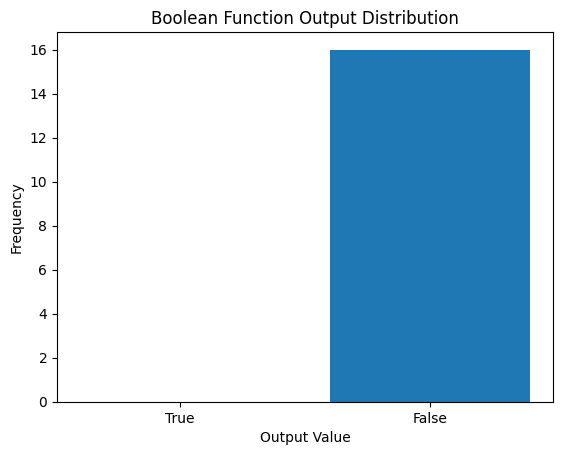

In [64]:
true_count = sum(df["Output"])
false_count = len(df) - true_count

plt.bar(["True", "False"], [true_count, false_count])
plt.title("Boolean Function Output Distribution")
plt.xlabel("Output Value")
plt.ylabel("Frequency")
plt.show()

## Summary

This visual representation clearly distinguishes constant vs balanced behaviour.

## Section 9: Boolean Function Pattern Check
### Explanation & Context

This section analyses whether a function is constant or balanced using simple logical conditions. Instead of manually inspecting outputs, we compute the number of True values and classify the function

In [67]:
# Classify the function based on the output distribution
true_count = sum(df["Output"])
total = len(df)

if true_count == 0 or true_count == total:
    result = "CONSTANT FUNCTION"
elif true_count == total // 2:
    result = "BALANCED FUNCTION"
else:
    result = "INVALID FUNCTION"

# Print the classification result
print("CLASSIFICATION:", result)

CLASSIFICATION: CONSTANT FUNCTION


## Summary

This provides an automatic classification method for any generated Boolean function.

## Section 10: Multiple Function Comparison Table
### Explanation & Context

To understand randomness in function generation, we generate multiple Boolean functions and classify each one. This allows comparison between constant and balanced functions across several runs, demonstrating that both types appear naturally in the generator.

In [70]:
# Generate multiple random functions and classify them
results = []

for i in range(10):
    f = random_constant_balanced()
    all_cases = list(itertools.product([False, True], repeat=4))
    outputs = [f(*inp) for inp in all_cases]

    true_count = sum(outputs)

    if true_count == 0 or true_count == 16:
        label = "CONSTANT"
    elif true_count == 8:
        label = "BALANCED"
    else:
        label = "INVALID"

    results.append((i+1, label))

# Display results in a DataFrame
df_results = pd.DataFrame(results, columns=["FUNCTION #", "TYPE"])
print(df_results)

   FUNCTION #      TYPE
0           1  CONSTANT
1           2  BALANCED
2           3  CONSTANT
3           4  BALANCED
4           5  BALANCED
5           6  BALANCED
6           7  BALANCED
7           8  CONSTANT
8           9  CONSTANT
9          10  CONSTANT


### Summary
This confirms that the generator produces a mix of constant and balanced functions across multiple trials.

## Problem 1: Conclusion

This implementation not only generates valid Boolean functions but also systematically verifies their structure using multiple complementary perspectives. These include raw evaluation of all possible inputs, structured tabular representations, visual analysis of output distributions, and classification based on numerical output counts. Together, these approaches provide a complete and consistent understanding of how constant and balanced Boolean functions behave under exhaustive input evaluation. This multi-representation approach strengthens confidence in the correctness of the implementation and clearly demonstrates the mathematical properties required by the problem.

## References

https://every-algorithm.github.io/2025/07/25/deutschjozsa_algorithm.html

https://www.numberanalytics.com/blog/explaining-deutsch-jozsa-algorithm

https://www.geeksforgeeks.org/digital-logic/boolean-functions/


https://docs.python.org/3/tutorial/controlflow.html#defining-functions

https://docs.python.org/3/library/random.html#random.sample

https://onlinetutorialhub.com/quantum-computing-tutorials/deutsch-algorithm-explained-in-quantum-computing/



## PROBLEM 2 CLASSICAL TESTING FOR FUNCTION TYPE

### Conceptual Explanation 

Classical computing uses bits that take values of either 0 or 1 and evaluates functions step by step. in constrast, quantum computing uses qubits, which can exist in superposition, allowing multiple inputs to be processed simultaneously. in this problem, a classical algorithm requires up to 16 evaluations of the function to determine whether it is constant or balanced. However, the Deutsh-Jozsa quantum algorithmn can solve the same problem with a single evaluation, demonstrating a significant advantage of quantum computation over classical methods. 

### Problem 1: 

CONSTANT = ALways Returns FALSE or Always TRUE 

BALANCED = Return TRUE for half and FALSE for the remaining


BOOLEAN FUNCTION Takes:  4 Inputs combinations

BOOLEAN FUNCTION Outputs: 1 Output 



### Solution

Determine a Boolean Function that takes Four inputs

1. Generate all possible 16 inputs

2. Evaluate the function 

3. Count Outputs

5. Classifying

6. Testing



In [29]:
#df["boolean_function(x)"] = df.apply(
    #lambda row: boolean_function(row["f1"], row["f2"], row["f3"], row["f4"]),
    #axis=1
#)
#df

In [30]:

# Create Determine_constant_balanced Function 
def determine_constant_balanced(test_function):

    # Step 1: Generate all input comibations (2^4 = 16)
    all_inputs = list(itertools.product([False, True], repeat=4))

    # Step 2: Evaluate the function for each input combination 
    outputs = [test_function(*input) for input in all_cases]

    # Step 3: Count how many outputs are TRUE or FALSE 
    True_num = sum(outputs) # True counts as 1, False as 0
    false_num = len(outputs) - true_num 

    # Step 4: Determine whether the function is Constant or Balanced
    if true_num == 0 or false_num == 0:

        # All outputs are the same -> Constant function 
        ftype = "constant "

    else:
        # Exactly half True and half False -> Balanced function 
        ftype = "balanced"

    # Step 5: Retrun the classification with counts
    return ftype, true_num, false_num

# Step 6: Generate a random test function (from problem 1)
test_function = random_constant_balanced()

# Step 7: analyse the function using classifier
result, true_num, false_num = determine_constant_balanced(test_function)

# Step 8: Display the Results
print("True outputs:", true_num)
print("False outputs:", false_num )
print("Detected type:", result )




True outputs: 16
False outputs: 0
Detected type: constant 


### Note 

The function evaluates all 16 possible input combinations of the boolean function. it counts the number of TRUE and the FALSE ouputs to determine whether the function is constant or balanced. in the worst case, all 16 evaluattions are required to guarantee correctness since checking fewer inputs may not distinguish between the two cases. Therefore, the maximum number of calls to the function is 16

### References

https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm

https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa

https://docs.classiq.io/latest/explore/algorithms/foundational/deutsch_jozsa/deutsch_jozsa/#the-quantum-part

https://medium.com/@ms_sidahmed/understanding-the-deutsch-jozsa-algorithm-a-quantum-advantage-6af4126af5bd





## PROBLEM 3: QUANTUM ORACLES


## Deutsh's Algorithm

It's purpose is to detrmine if a function is constant or balanced with one query

### Function:
    f(x): {0, 1} -> {0, 1}

There are Four Possible Functions 

###  Four Boolean Functions

  ### 1. Constant
       . f(x) = 0
       . f(x) = 1
  ### 2. Balanced
       . f(x) = 0
       . f(x) = 1 - 0

  ### 1. Constant -> same outputs for all inputs
  ### 2. Balanced -> outputs differ for inputs

##  Quantum Oracle

Quantum oracle is a black-box operation that encodes the function f(x). The oracle for(x) is represented by a unitary transformation Uf. (https://onlinetutorialhub.com/quantum-computing-tutorials/deutsch-algorithm-explained-in-quantum-computing/).

## Unitary Transformation

It is define as:
#### |x⟩|y⟩ → |x⟩|y ⊕ f(x)⟩

#### Key points:
. X  is the input

. Y  is an auxiliary qubit

. ⊕ denotes addition modulo 2

## Oracle Strategy

Oracle are built using X and CX

. No change - Identity

. Flip -> X gate

. Conditional flip -> CNOT

. Input qubit = control

. Output qubit = target


### Notes

 ### Reference

## PROBLEM 4: DEUTSH'S ALGORITHM WITH QISKIT

## PROBLEM 5: SCALING TO THE DEUTSH-JOZSA ALGORITHMN